170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2360s 14us/step


C:\Users\Smile\AppData\Roaming\Python\Python314\site-packages\keras\src\datasets\cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = RestrictedUnpickler(f, encoding="bytes").load()
C:\Users\Smile\AppData\Roaming\Python\Python314\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten (Flatten)                    │ (None, 3072)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │       1,573,376 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,738,890 (6.63 MB)

 Trainable params: 1,738,890 (6.63 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 85s 133ms/step - accuracy: 0.3153 - loss: 1.8916 - val_accuracy: 0.3579 - val_loss: 1.7817
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 40s 64ms/step - accuracy: 0.3860 - loss: 1.7016 - val_accuracy: 0.3880 - val_loss: 1.7192
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 35s 57ms/step - accuracy: 0.4250 - loss: 1.6090 - val_accuracy: 0.4103 - val_loss: 1.6413
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 32s 51ms/step - accuracy: 0.4434 - loss: 1.5576 - val_accuracy: 0.4395 - val_loss: 1.5783
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 30s 47ms/step - accuracy: 0.4600 - loss: 1.5033 - val_accuracy: 0.4451 - val_loss: 1.5560
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 30s 48ms/step - accuracy: 0.4752 - loss: 1.4712 - val_accuracy: 0.4604 - val_loss: 1.5281
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 32s 51ms/step - accuracy: 0.4868 - loss: 1.4412 - val_accuracy: 0.4616 - val_loss: 1.5173
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 30s 48ms/step - accuracy: 0.4938 - loss: 1.4134 -

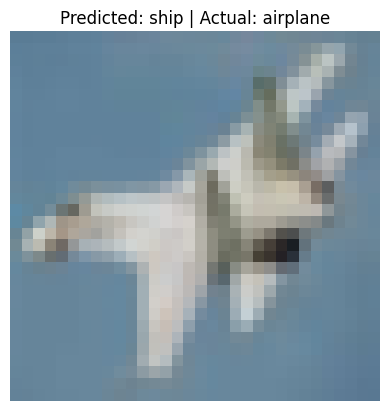

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import keras

from keras.datasets import cifar10
from keras.models import Sequential
from keras.layers import Flatten, Dense
from keras.utils import to_categorical


# ============================================
# 1. Load CIFAR-10
# ============================================

(X_train, y_train), (X_test, y_test) = cifar10.load_data()


# ============================================
# 2. Normalize
# ============================================

X_train = X_train / 255.0
X_test = X_test / 255.0


# ============================================
# 3. One-hot encode labels
# ============================================

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)


# ============================================
# 4. Build ANN
# ============================================

model = Sequential([
    
    Flatten(input_shape=(32, 32, 3)),
    
    Dense(512, activation='relu'),
    
    Dense(256, activation='relu'),
    
    Dense(128, activation='relu'),
    
    Dense(10, activation='softmax')
])


# ============================================
# 5. Compile
# ============================================

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


# ============================================
# 6. Model summary
# ============================================

model.summary()


# ============================================
# 7. Train
# ============================================

history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.2
)


# ============================================
# 8. Evaluate
# ============================================

test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)


# ============================================
# 9. Predictions
# ============================================

predictions = model.predict(X_test)


# ============================================
# 10. Class names
# ============================================

class_names = [
    'airplane',
    'automobile',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck'
]


# ============================================
# 11. Display prediction
# ============================================

index = 10

predicted_class = np.argmax(predictions[index])
actual_class = np.argmax(y_test[index])

plt.imshow(X_test[index])
plt.axis('off')

plt.title(
    f"Predicted: {class_names[predicted_class]} | "
    f"Actual: {class_names[actual_class]}"
)

plt.show()

## To test outside data

In [16]:
model.save("cifar10_ann.h5")

In [21]:
from keras.models import load_model
model = load_model("cifar10_ann.h5")

from keras.utils import load_img

image = load_img(
    r"C:\Users\Smile\Pictures\Screenshots\Screenshot 2026-09-16 182038.png",
    target_size=(32, 32)
)

# CIFAR-10 class names
class_names = [
    'airplane',
    'automobile',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck'
]


def predict_external_image(image_path):

    # 1. Load image
    image = load_img(
        image_path,
        target_size=(32, 32)
    )

    # 2. Convert image to NumPy array
    image_array = np.array(image)

    # 3. Normalize
    image_array = image_array / 255.0

    # 4. Add batch dimension
    image_array = np.expand_dims(image_array, axis=0)

    # 5. Prediction
    prediction = model.predict(image_array, verbose=0)

    # 6. Get predicted class
    predicted_class = np.argmax(prediction[0])

    # 7. Get confidence
    confidence = prediction[0][predicted_class]

    # 8. Display result
    plt.imshow(image)
    plt.axis('off')

    plt.title(
        f"Prediction: {class_names[predicted_class]}\n"
        f"Confidence: {confidence * 100:.2f}%"
    )

    plt.show()

    return class_names[predicted_class], confidence

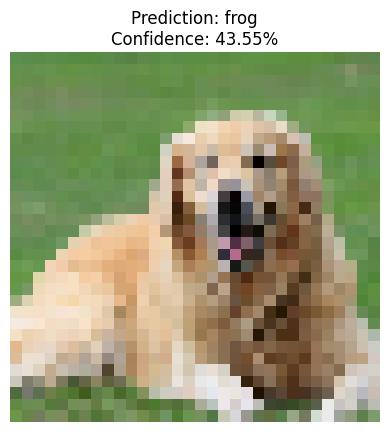

('frog', np.float32(0.43549436))

In [23]:
predict_external_image( r"C:\Users\Smile\Pictures\Screenshots\Screenshot 2026-09-16 184742.png")